## Environment setup

In [1]:
from datetime import datetime 
import importlib
from functools import partial

import tensorflow as tf
from tensorflow.data import Dataset, TFRecordDataset
import tensorflow_datasets as tfds

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

# Notebooks run from VSCode use home directory as a base path
# while notebooks ran from JupyterLab use the current directory as a base path
import sys
sys.path.append("/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/")

# Change directory to the working directory
import os
os.chdir('/scratch_hdd/akalinow/ELITPC/PythonAnalysis/')

#Increase plots font size
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (10, 7),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

2025-11-25 14:58:15.959318: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Load the dataset and convert to pandas DataFrame

In [2]:
%%time 

import utility_functions as utils
importlib.reload(utils)

dataset = tf.data.Dataset.load('MergedEvent_Track3D_TwoProng_gun_MC_100k', compression="GZIP")

data = dataset.map(lambda x: tf.reshape(x["sim"][1], (1,-1))).unbatch().as_numpy_iterator()
df = pd.DataFrame(data, columns=utils.columnsXYZ)

data = dataset.map(lambda x: tf.reshape(x["reco"][1], (1,-1))).unbatch().as_numpy_iterator()
df_reco = pd.DataFrame(data, columns=utils.columnsXYZ)

df = df.merge(df_reco, left_index=True, right_index=True, suffixes=("_sim", "_reco"), how="outer");

Cause: could not parse the source code of <function <lambda> at 0x754a3c043240>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x754a3c043240>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-11-25 14:58:26.708488: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-11-25 14:58:26.710867: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-11-25 14:58:26.721997: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Cause: could not parse the source code of <function <lambda> at 0x754b54709c60>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x754b54709c60>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-11-25 15:01:27.146099: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


CPU times: user 6min 33s, sys: 3.99 s, total: 6min 37s
Wall time: 5min 58s


2025-11-25 15:04:25.172832: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Load the model


In [3]:
path = '/home/akalinow/scratch/ELITPC/PythonAnalysis/training/0100_2025_Jul_16_20_39_42.keras'
model = tf.keras.models.load_model(path)

I0000 00:00:1764079485.501599 1278323 service.cc:145] XLA service 0x1fc81090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764079485.501624 1278323 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
I0000 00:00:1764079485.501629 1278323 service.cc:153]   StreamExecutor device (1): NVIDIA GeForce RTX 2070 SUPER, Compute Capability 7.5
2025-11-25 15:04:45.530018: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8906
I0000 00:00:1764079486.379550 1278323 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


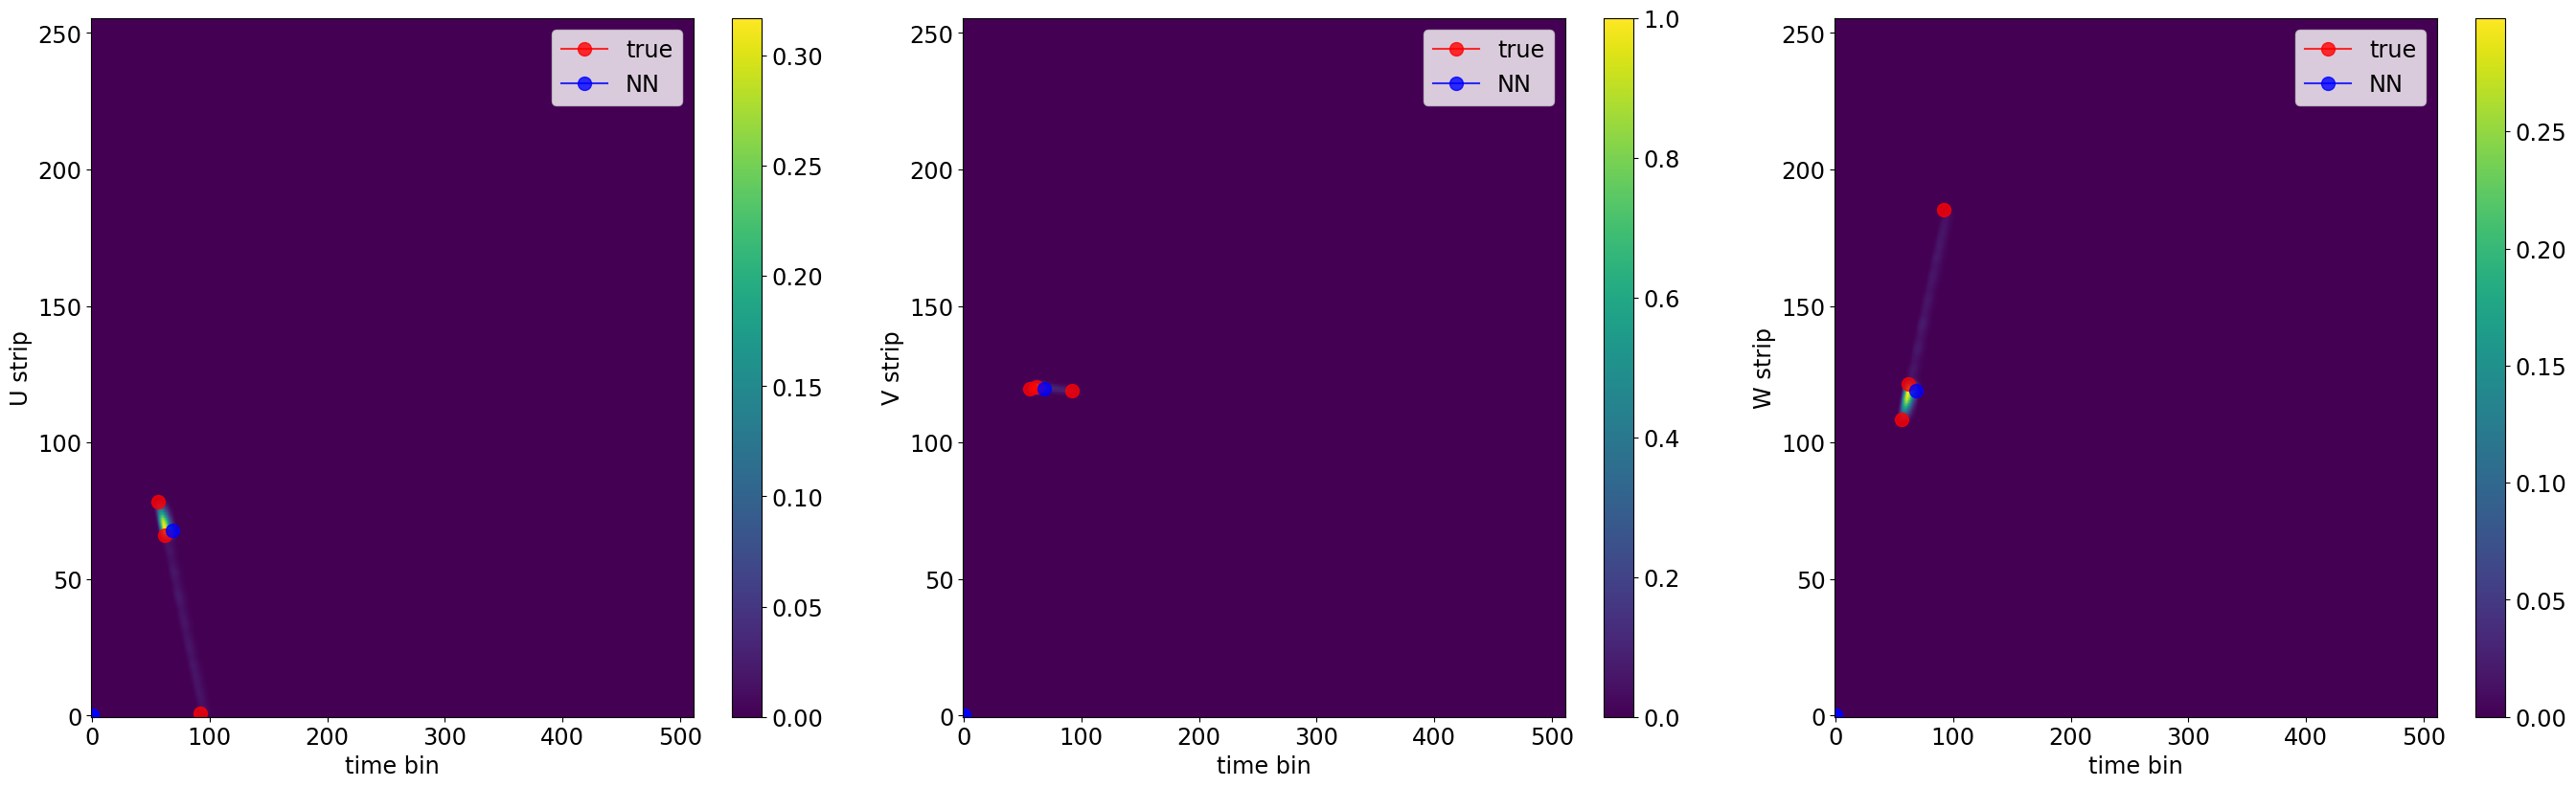

In [4]:
import plotting_functions as plf
importlib.reload(plf)

dataset_f = dataset.map(lambda x: (tf.where(x['sim'][0]>0.1, x['sim'][0], 0), x['sim'][1]))

x = iter(dataset.batch(1))
for i in range(1):
    item = next(x)
    plf.plotEvent(item['sim'], model=model)

### Resolution plots in XYZ

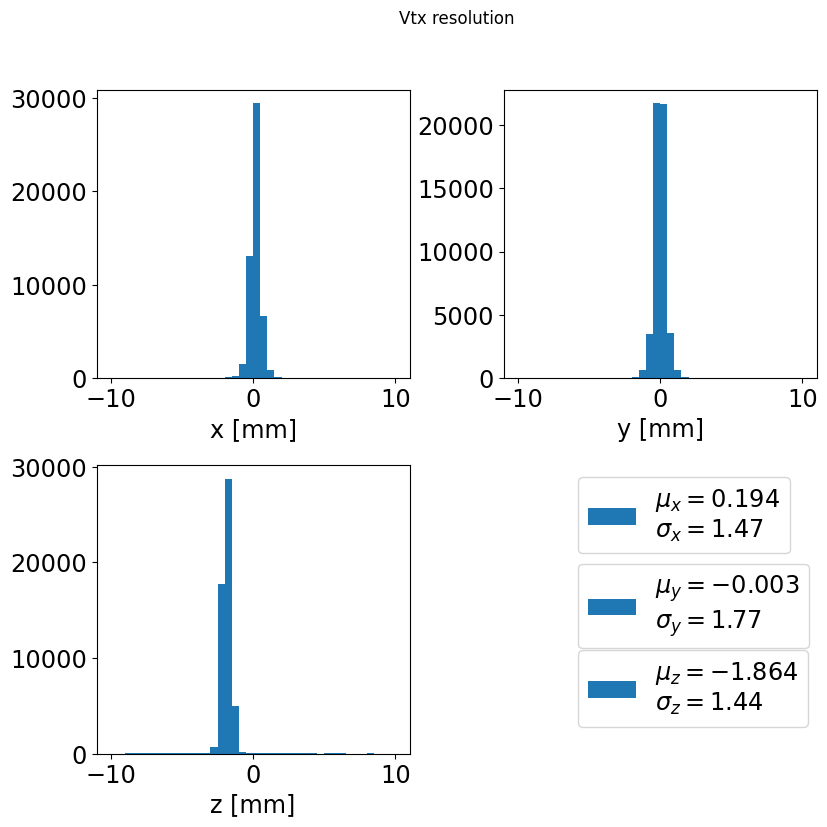

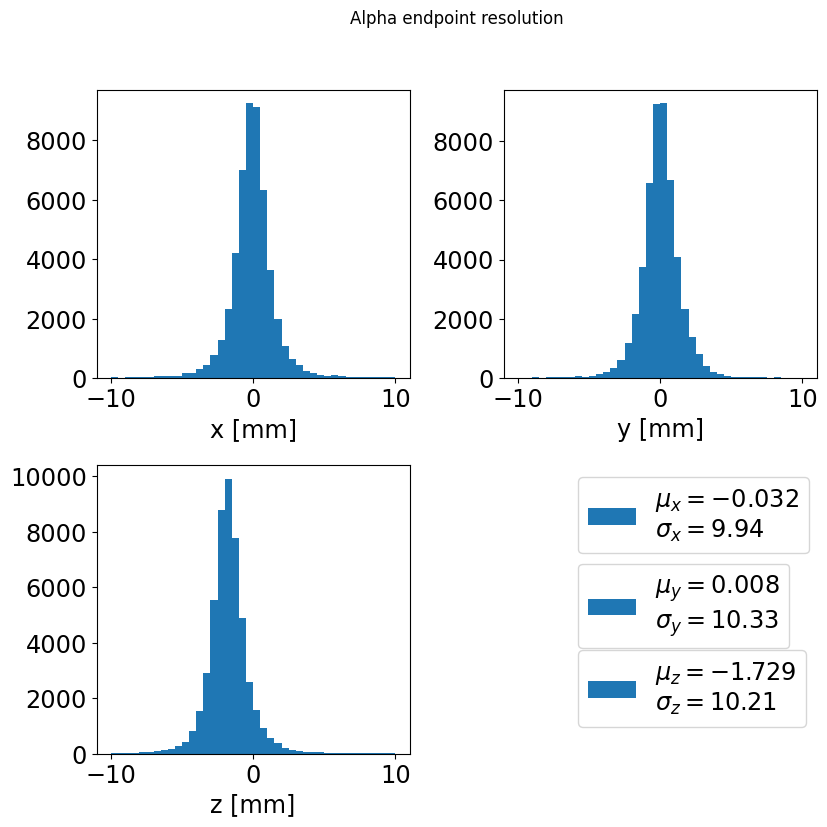

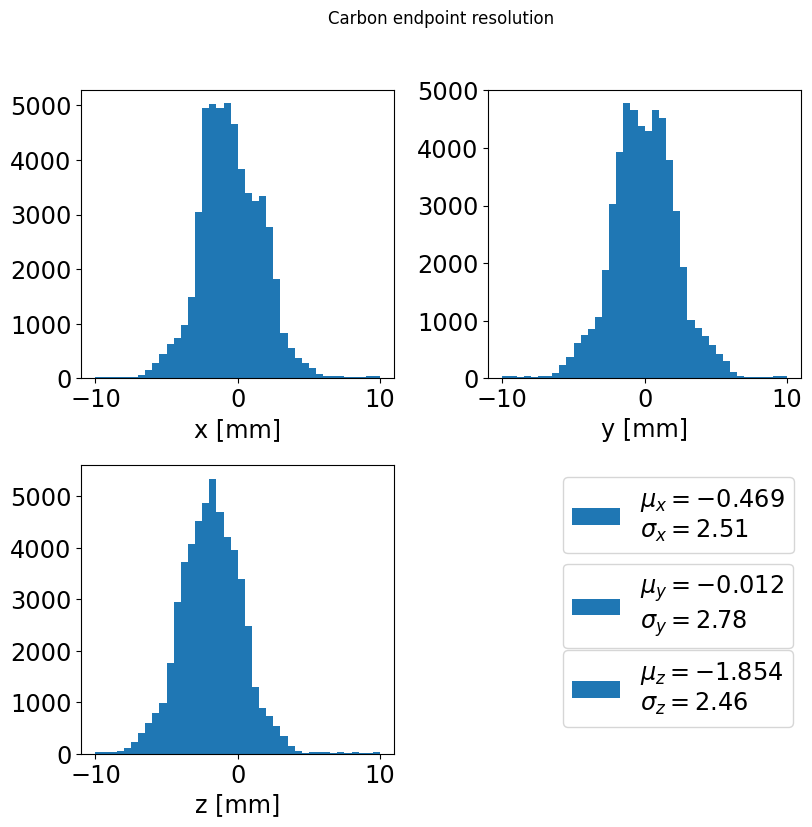

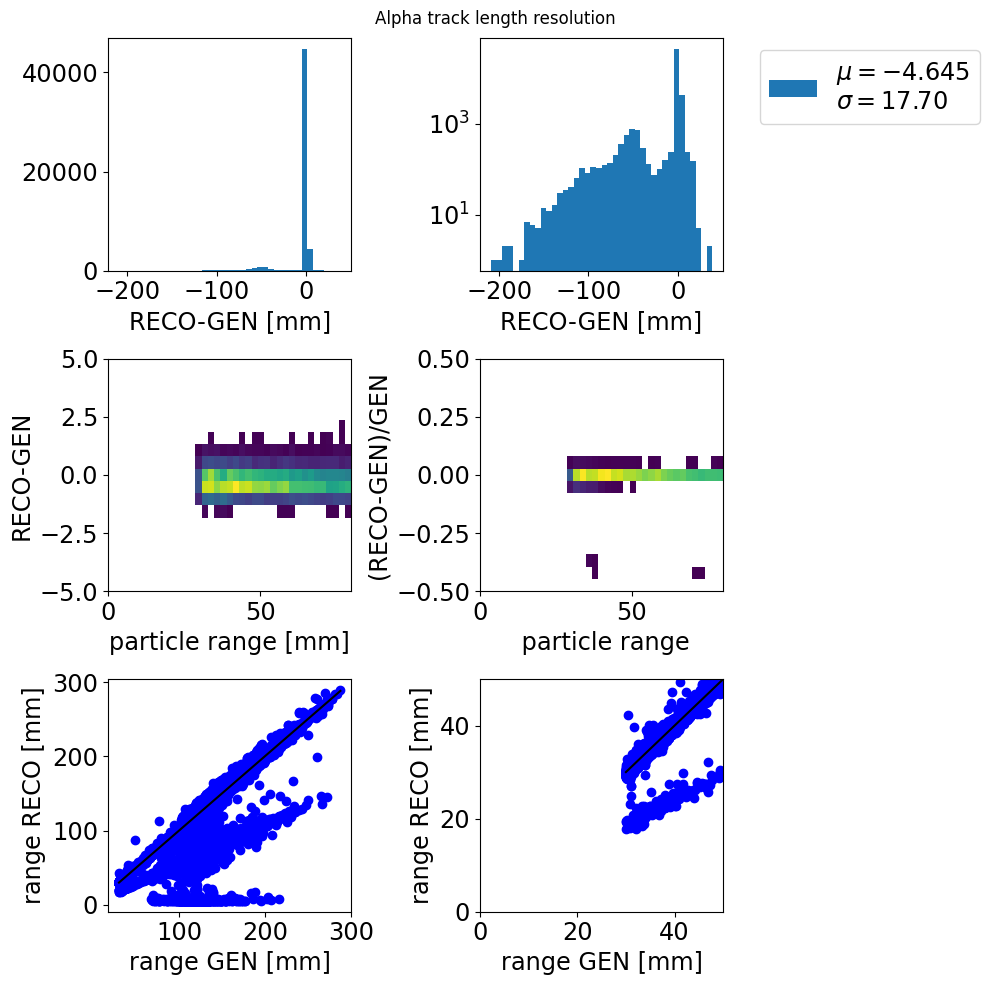

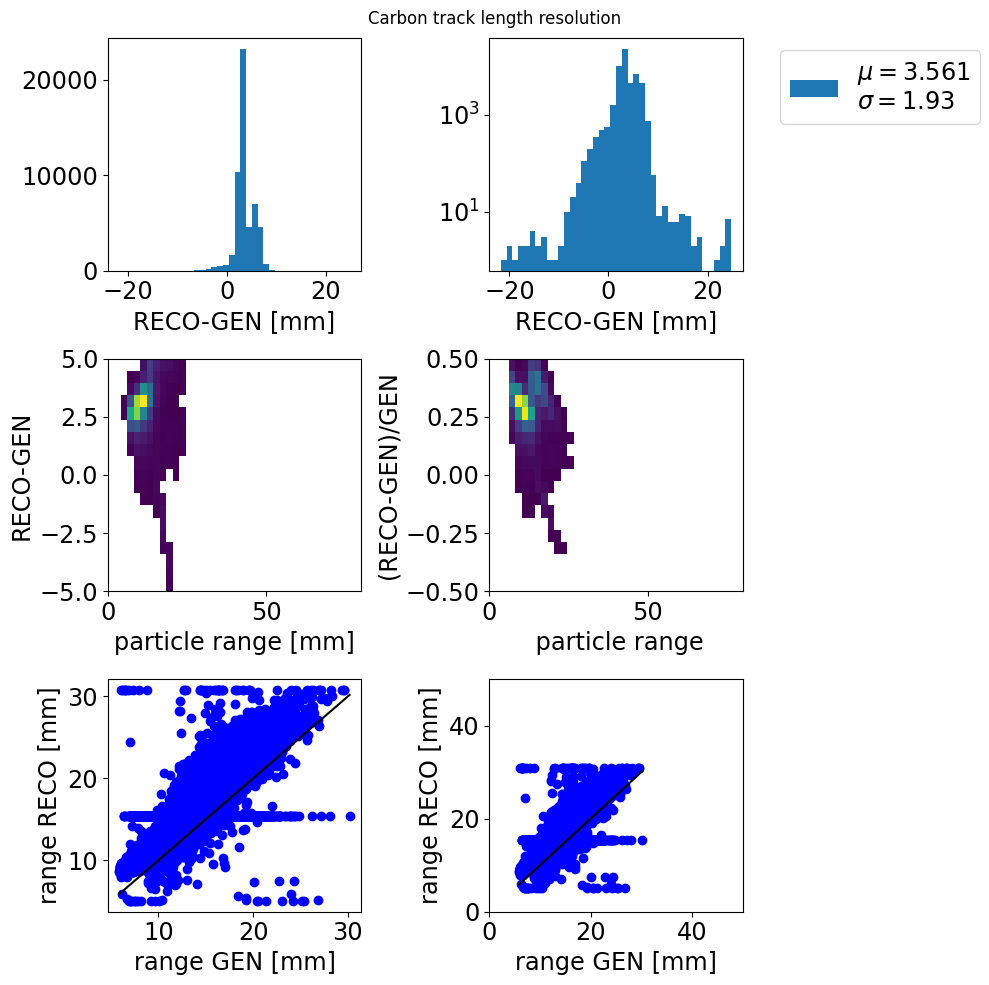

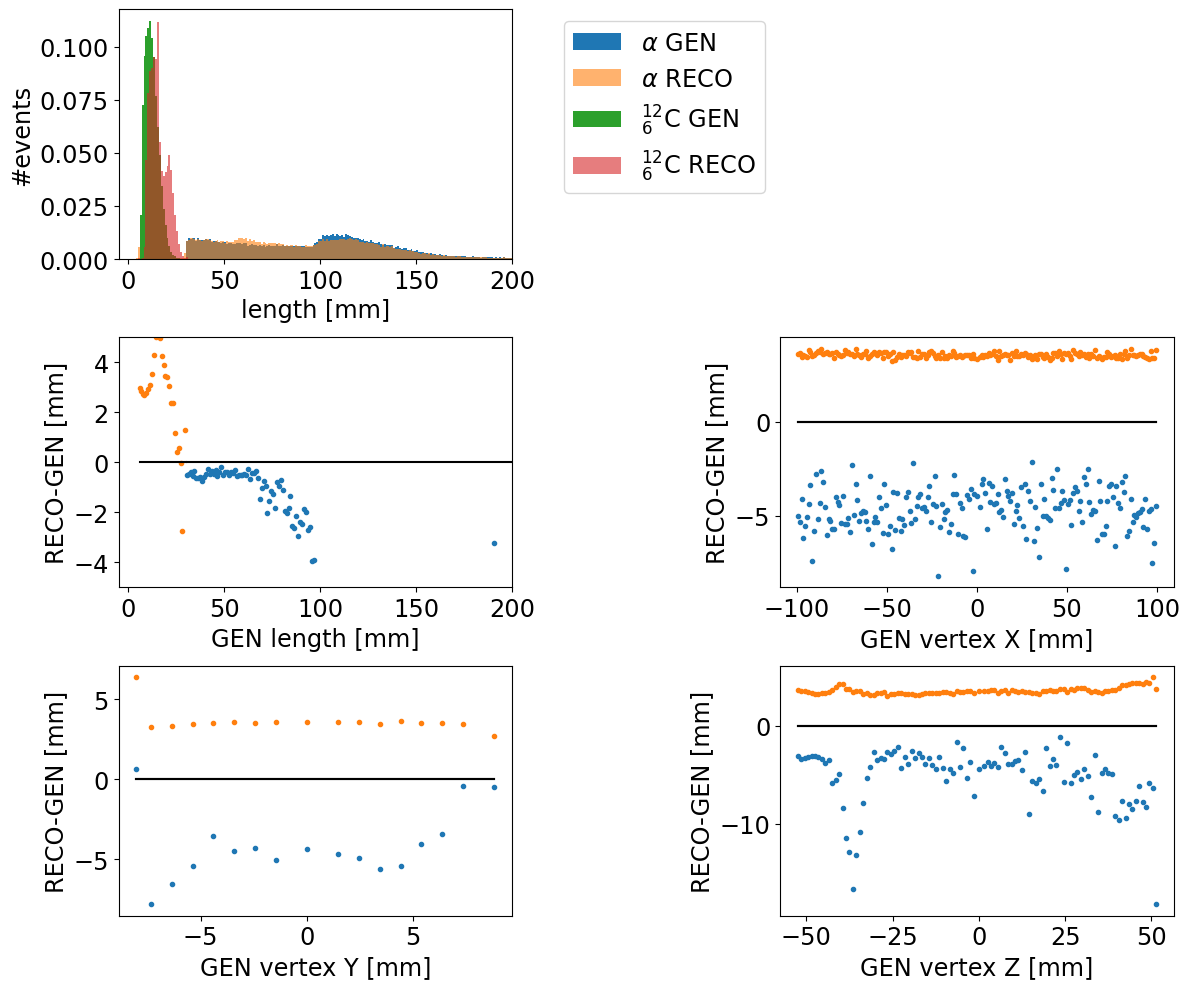

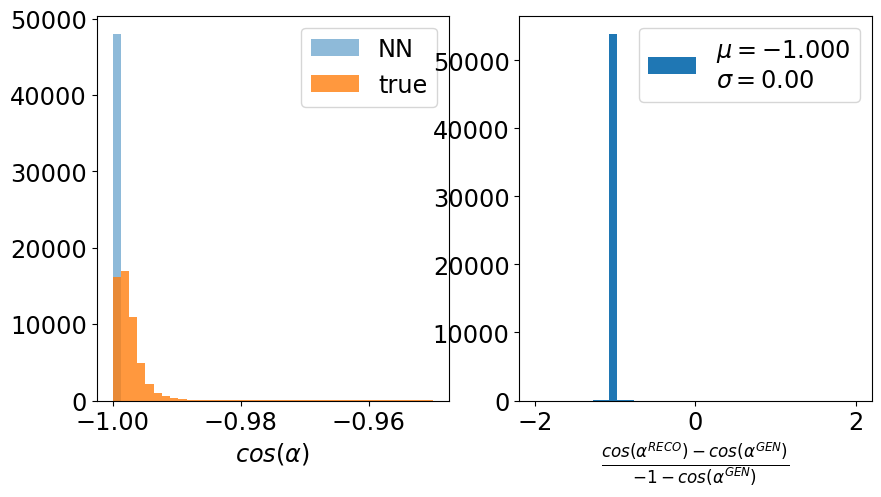

In [6]:
import plotting_functions as plf
importlib.reload(plf)

#plf.controlPlots(df)
plf.plotEndPointRes(df=df, edge="Vtx", coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df, edge="Alpha", coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df, edge="Carbon", coordinates=["x", "y", "z"])

plf.plotLengthPull(df, partName="Alpha")
plf.plotLengthPull(df, partName="Carbon")
plf.plotLengthPullEvolution(df)
plf.plotOpeningAngleCos(df)

### Resolution plots for filtered dataset

In [ ]:
import plotting_functions as plf
importlib.reload(plf)

partName = "Carbon"
d_reco = np.sqrt((df["x"+partName+"_reco"] - df["xVtx_reco"])**2 + 
                     (df["y"+partName+"_reco"] - df["yVtx_reco"])**2 + 
                     (df["z"+partName+"_reco"] - df["zVtx_reco"])**2 )


partName = "Alpha"
d_sim = np.sqrt((df["x"+partName+"_sim"] - df["xVtx_sim"])**2 + 
                     (df["y"+partName+"_sim"] - df["yVtx_sim"])**2 + 
                     (df["z"+partName+"_sim"] - df["zVtx_sim"])**2 )

#mask = (df["pullAlpha"]<-10)*(np.abs(df["xAlpha_sim"])<100)*(np.abs(df["yAlpha_sim"])<90)*(np.abs(df["zAlpha_sim"])<50)
mask = np.abs(d_reco-15)>1
mask = d_sim<65

plf.controlPlots(df[mask])
plf.plotEndPointRes(df=df[mask], edge="Vtx", coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df[mask], edge="Alpha", coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df[mask], edge="Carbon", coordinates=["x", "y", "z"])

plf.plotLengthPull(df[mask], partName="Alpha")
plf.plotLengthPull(df[mask], partName="Carbon")
plf.plotLengthPullEvolution(df[mask])

### Resolution plots in UVWT

In [8]:
import utility_functions as utils
importlib.reload(utils)

batchSize = 32
dataset = tf.data.Dataset.load('MergedEvent_Track3D_TwoProng_gun_MC_100k', compression="GZIP")

data = dataset.map(lambda x: tf.reshape(x["sim"][1], (1,-1)))
data = data.map(lambda x: tf.reshape(x, (-1,3,3)))
data = data.map(lambda x: utils.XYZtoUVWT_event(x))
data = data.map(lambda x: tf.reshape(x, (-1,12))).unbatch().as_numpy_iterator()

df = pd.DataFrame(data, columns=utils.columnsUVWT)


data = dataset.map(lambda x: tf.reshape(x["reco"][1], (1,-1)))
data = data.map(lambda x: tf.reshape(x, (-1,3,3)))
data = data.map(lambda x: utils.XYZtoUVWT_event(x))
data = data.map(lambda x: tf.reshape(x, (-1,12))).unbatch().as_numpy_iterator()
df_reco = pd.DataFrame(data, columns=utils.columnsUVWT)

df = df.merge(df_reco, left_index=True, right_index=True, suffixes=("_sim", "_reco"), how="outer");

2025-11-25 15:09:41.531746: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-25 15:12:39.776707: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


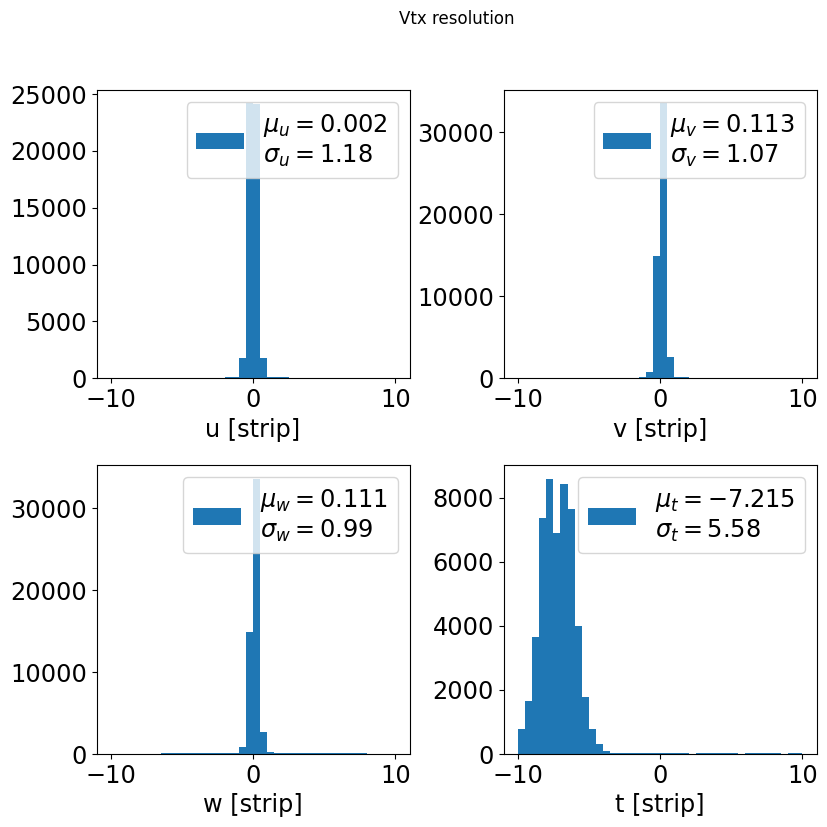

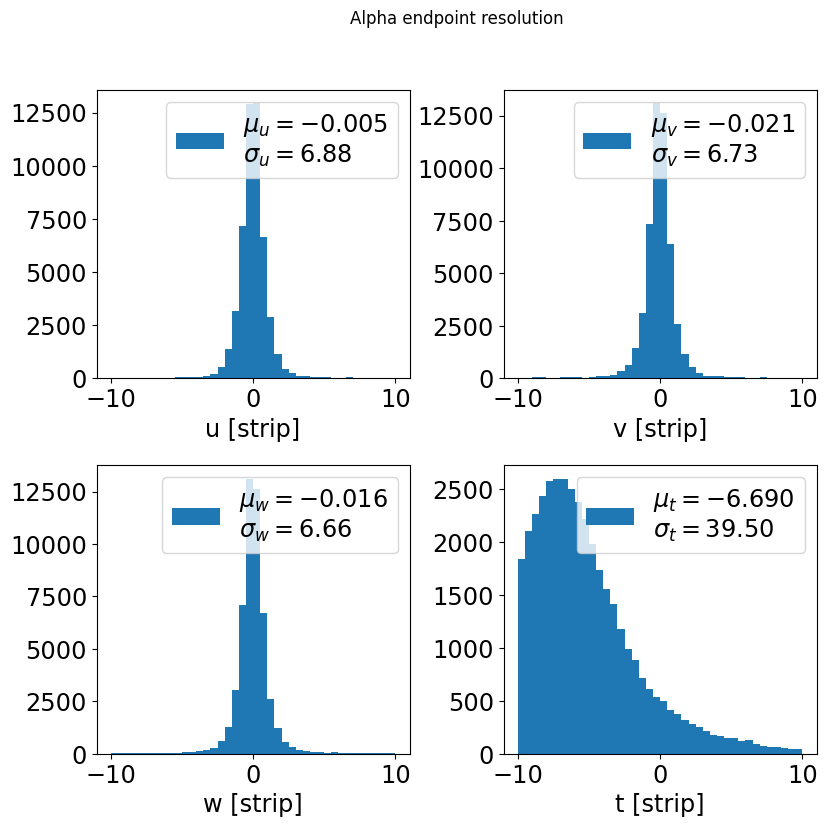

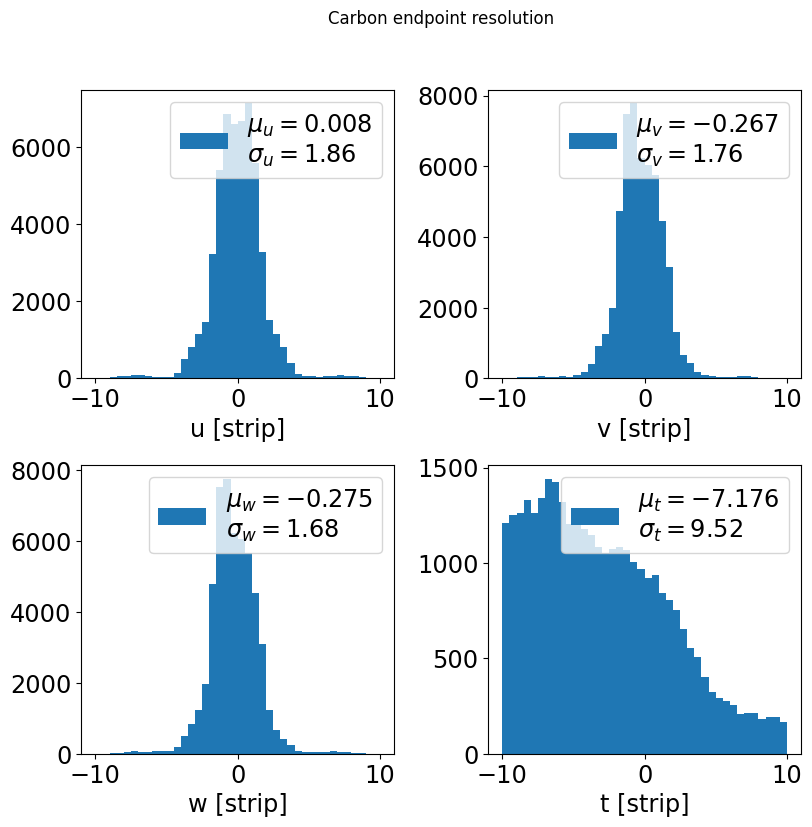

In [9]:
import plotting_functions as plf
importlib.reload(plf)

plf.plotEndPointRes(df=df, edge="Vtx", coordinates=["u", "v", "w", "t"])
plf.plotEndPointRes(df=df, edge="Alpha", coordinates=["u", "v", "w", "t"])
plf.plotEndPointRes(df=df, edge="Carbon", coordinates=["u", "v", "w", "t"])